In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns if needed
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\notebooks


In [4]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [5]:
import os
print(os.getcwd())

c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\notebooks


In [6]:
import os

print(os.listdir())

['Advanced_Analytics.ipynb']


In [7]:
import os
print(os.getcwd())

c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\notebooks


In [8]:
import os

project_root = os.path.dirname(os.getcwd())  # Go up from notebooks to Mutual_Fund

for root, dirs, files in os.walk(project_root):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\02_nav_history.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\07_scheme_performance.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\08_investor_transactions.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\cagr_comparison.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\daily_returns.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\fund_scorecard.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\maximum_drawdown.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\sortino_ratio.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\processed\tracking_error.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\raw\01_fund_master.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\raw\02_nav_history.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\raw\03_aum_by_fund_house.csv
c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\data\raw\04_monthly_sip_inf

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
nav = pd.read_csv("../data/processed/02_nav_history.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)


In [10]:
print("===== NAV Columns =====")
print(nav.columns.tolist())

print("\n===== Transactions Columns =====")
print(transactions.columns.tolist())

===== NAV Columns =====
['amfi_code', 'date', 'nav']

===== Transactions Columns =====
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [11]:
nav.info()

transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gen

In [12]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nTransactions Columns:")
print(transactions.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

Transactions Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [13]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nTransactions Columns:")
print(transactions.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

Transactions Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [14]:
# Convert dates into datetime format
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print("Dates converted successfully!")

Dates converted successfully!


In [15]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [16]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [17]:
returns = nav.dropna(subset=["daily_return"])

print(returns.head())

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639


In [18]:
var = (
    returns.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var.columns = ["amfi_code", "VaR_95"]

var.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [19]:
cvar_list = []

for code in returns["amfi_code"].unique():

    temp = returns[returns["amfi_code"] == code]

    threshold = temp["daily_return"].quantile(0.05)

    cvar = temp[temp["daily_return"] <= threshold]["daily_return"].mean()

    cvar_list.append([code, cvar])

cvar = pd.DataFrame(cvar_list, columns=["amfi_code", "CVaR"])

cvar.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [20]:
risk_report = var.merge(cvar, on="amfi_code")

risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [21]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR/CVaR report saved successfully!")

VaR/CVaR report saved successfully!


In [22]:
returns["amfi_code"].unique()

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632, 118633, 118634, 118635, 118636, 119092, 119093,
       119094, 119095, 119120, 119551, 119552, 119598, 119599, 120503,
       120504, 120505, 120506, 120507, 120841, 120842, 120843, 120844,
       125497, 125498, 148567, 148568, 148569, 149322, 149323, 149324])

In [23]:
funds = returns["amfi_code"].unique()[:5]

print(funds)

[100016 100025 100033 101206 101207]


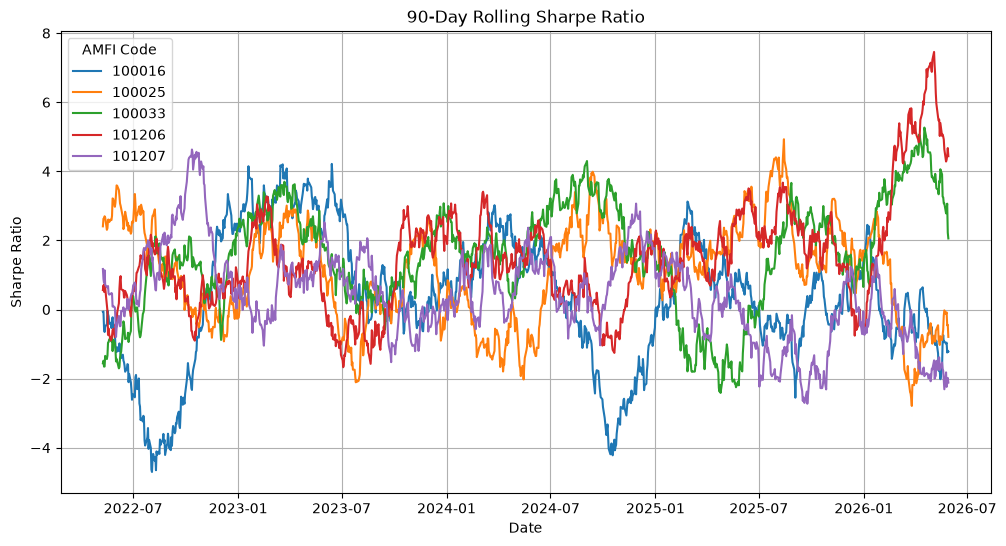

In [24]:
plt.figure(figsize=(12,6))

for fund in funds:

    temp = returns[returns["amfi_code"] == fund].copy()

    temp["Rolling_Sharpe"] = (
        temp["daily_return"].rolling(90).mean()
        /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["Rolling_Sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

In [25]:
sharpe = (
    returns.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe["sharpe_ratio"] = (
    sharpe["mean"] / sharpe["std"]
) * np.sqrt(252)

sharpe = sharpe[["amfi_code", "sharpe_ratio"]]

sharpe.head()

,amfi_code,sharpe_ratio
0,100016,0.245276
1,100025,1.097333
2,100033,1.436947
3,101206,1.473390
4,101207,0.414625


In [26]:
# Find each investor's first transaction year
transactions["cohort_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [27]:
avg_sip = (
    transactions.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="Average_SIP_Amount")
)

avg_sip

,cohort_year,Average_SIP_Amount
0,2024,107422.541832
1,2025,109158.577061


In [28]:
total_investment = (
    transactions.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="Total_Investment")
)

total_investment

,cohort_year,Total_Investment
0,2024,3491125187
1,2025,30455243


In [29]:
top_fund = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [30]:
cohort_summary = (
    avg_sip
    .merge(total_investment, on="cohort_year")
    .merge(top_fund[["cohort_year", "amfi_code"]], on="cohort_year")
)

cohort_summary

,cohort_year,Average_SIP_Amount,Total_Investment,amfi_code
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [31]:
sip = (
    transactions.groupby("investor_id")
    .filter(lambda x: len(x) >= 6)
)

print("Number of eligible investors:", sip["investor_id"].nunique())

Number of eligible investors: 2950


In [32]:
sip = sip.sort_values(["investor_id", "transaction_date"])

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
17587,INV000002,2024-10-03,101207,Lumpsum,203094,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,12.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,112.0


In [33]:
gap_summary = (
    sip.groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="Average_Gap_Days")
)

gap_summary.head()

,investor_id,Average_Gap_Days
0,INV000002,82.800000
1,INV000004,53.375000
2,INV000005,52.000000
3,INV000006,99.000000
4,INV000008,50.285714


In [34]:
gap_summary["status"] = np.where(
    gap_summary["Average_Gap_Days"] > 35,
    "At Risk",
    "Regular"
)

gap_summary.head()

,investor_id,Average_Gap_Days,status
0,INV000002,82.800000,At Risk
1,INV000004,53.375000,At Risk
2,INV000005,52.000000,At Risk
3,INV000006,99.000000,At Risk
4,INV000008,50.285714,At Risk


In [35]:
continuity_rate = (
    (gap_summary["status"] == "Regular").mean() * 100
)

print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

SIP Continuity Rate: 6.37%


In [36]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [37]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Portfolio Shape:", portfolio.shape)
print(portfolio.columns.tolist())

Portfolio Shape: (322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [38]:
import os
print(os.getcwd())

c:\Users\Dell\OneDrive\Desktop\Mutual_Fund\notebooks


In [39]:
# Convert percentage to decimal
portfolio["weight"] = portfolio["weight_pct"] / 100

# Square each weight
portfolio["weight_square"] = portfolio["weight"] ** 2

# Calculate HHI for each fund
hhi = (
    portfolio.groupby("amfi_code")["weight_square"]
    .sum()
    .reset_index()
)

hhi.rename(columns={"weight_square": "HHI"}, inplace=True)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [40]:
hhi["Concentration"] = np.where(
    hhi["HHI"] > 0.25,
    "Highly Concentrated",
    "Diversified"
)

hhi.head()

,amfi_code,HHI,Concentration
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Diversified
4,102885,0.174709,Diversified


In [41]:
top_hhi = hhi.sort_values("HHI", ascending=False)

top_hhi.head(10)

,amfi_code,HHI,Concentration
11,119092,0.206448,Diversified
3,101207,0.200700,Diversified
18,119599,0.174751,Diversified
4,102885,0.174709,Diversified
7,118632,0.168298,Diversified
29,148568,0.167930,Diversified
21,120505,0.157570,Diversified
22,120506,0.153794,Diversified
27,125498,0.152414,Diversified
23,120841,0.149680,Diversified


In [42]:
hhi.to_csv("../reports/sector_hhi_report.csv", index=False)

print("Sector HHI report saved successfully!")

Sector HHI report saved successfully!
